# Classificazione dell'Abbandono Aziendale (Employee Attrition): Data classification
**Business Intelligence per Big Data — Politecnico di Torino, AA 2025-2026**

**Obiettivo:** predire se un dipendente lascerà l'azienda (Attrition = 1) o rimarrà (Attrition = 0), usando algoritmi di classificazione supervisionata. Il modello supporta le strategie di retention HR identificando preventivamente i dipendenti a rischio.

## 1. Import Librerie

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, roc_curve)
random_seed = 42
import warnings
warnings.simplefilter("ignore", UserWarning)

## 2. Caricamento dei Dati

In [5]:
base_path = 'datasets_post_processing/'

train_with_label = pd.read_excel(base_path + 'train_with_label_dataPrep.xlsx')
test_with_label  = pd.read_excel(base_path + 'test_dataPrep.xlsx')
X_train = train_with_label.drop(columns=['Attrition'])
y_train = train_with_label['Attrition']

X_test = test_with_label.drop(columns=['Attrition'])
y_test  = test_with_label['Attrition']




In [6]:
# PER PROVA CON DATI SENZA PREPROCESSING
'''
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Carica i dati grezzi
base_path_raw = 'C:/Users/criba/OneDrive/Desktop/BusinessIntelligencePersonal/materiale_attrition/'
train_raw = pd.read_excel(base_path_raw + 'attrition_train.xlsx')
test_raw  = pd.read_excel(base_path_raw + 'attrition_test.xlsx')

# Rimuovi colonne inutili
drop_cols = ['EmployeeID'] if 'EmployeeID' in train_raw.columns else []
train_raw = train_raw.drop(columns=drop_cols)
test_raw  = test_raw.drop(columns=drop_cols)

# Separa target
y_train = train_raw['Attrition']
y_test  = test_raw['Attrition']
X_train_raw = train_raw.drop(columns=['Attrition'])
X_test_raw  = test_raw.drop(columns=['Attrition'])

# One-hot encoding variabili nominali
onehot_cols = ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']
X_train_raw = pd.get_dummies(X_train_raw, columns=onehot_cols)
X_test_raw  = pd.get_dummies(X_test_raw,  columns=onehot_cols)

# Allineamento colonne train/test
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)

# Normalizzazione MinMax fittata solo sul train
scaler_raw = MinMaxScaler()
X_train = pd.DataFrame(scaler_raw.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(scaler_raw.transform(X_test_raw),      columns=X_train_raw.columns)
'''


"\nimport pandas as pd\nimport numpy as np\nfrom sklearn.preprocessing import MinMaxScaler\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.tree import DecisionTreeClassifier\nfrom sklearn.ensemble import RandomForestClassifier\n\n# Carica i dati grezzi\nbase_path_raw = 'C:/Users/criba/OneDrive/Desktop/BusinessIntelligencePersonal/materiale_attrition/'\ntrain_raw = pd.read_excel(base_path_raw + 'attrition_train.xlsx')\ntest_raw  = pd.read_excel(base_path_raw + 'attrition_test.xlsx')\n\n# Rimuovi colonne inutili\ndrop_cols = ['EmployeeID'] if 'EmployeeID' in train_raw.columns else []\ntrain_raw = train_raw.drop(columns=drop_cols)\ntest_raw  = test_raw.drop(columns=drop_cols)\n\n# Separa target\ny_train = train_raw['Attrition']\ny_test  = test_raw['Attrition']\nX_train_raw = train_raw.drop(columns=['Attrition'])\nX_test_raw  = test_raw.drop(columns=['Attrition'])\n\n# One-hot encoding variabili nominali\nonehot_cols = ['Gender', 'MaritalStatus', 'EducationField', 'Depar

In [7]:
## UTILS per CROSS-VALIDATION


def evaluate(y_true, y_pred, y_prob, nome_modello):
    """
    Stampa classification report, confusion matrix e metriche principali.
    Ritorna un dizionario con le metriche per il confronto finale.
    """
    print(f"=== {nome_modello} ===")
    print(classification_report(y_true, y_pred, target_names=['Rimasto', 'Uscito']))

    cm = pd.DataFrame(confusion_matrix(y_true, y_pred),index=['Reale: Rimasto', 'Reale: Uscito'],columns=['Pred: Rimasto', 'Pred: Uscito'])
    print('Confusion Matrix:')
    print(cm)
    print()

    return {
        'Modello'  : nome_modello,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'AUC'      : roc_auc_score(y_true, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }


def plot_gridsearch_heatmap(gs, param_x, param_y, title):
    """Heatmap F1 per ogni combinazione di iperparametri esplorata dalla GridSearch."""
    cv_res = pd.DataFrame(gs.cv_results_)
    cv_res[param_y] = cv_res[param_y].fillna('None')
    pivot = cv_res.pivot_table(values='mean_test_score', index=param_y, columns=param_x)
    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()
# StratifiedKFold mantiene la proporzione di classi in ogni fold, utile con dataset sbilanciato (15% Attrition=1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

## 3. Decision Tree

Il Decision Tree costruisce una struttura ad albero partizionando ricorsivamente
i dati secondo una misura di impurità. Ad ogni nodo viene scelto l'attributo che
massimizza la riduzione di impurità (Information Gain o Gini).

**Criterio Entropy (Information Gain):**
$$GAIN_{split} = Entropy(p) - \sum_{i=1}^{k} \frac{n_i}{n} Entropy(i)$$

**Criterio Gini:**
$$GINI(t) = 1 - \sum_{j} [p(j|t)]^2$$

Il parametro `max_depth` controlla la profondità massima dell'albero — valori
troppo alti portano a overfitting, valori troppo bassi a underfitting.
Il parametro `class_weight='balanced'` compensa lo sbilanciamento tra le classi
assegnando pesi inversamente proporzionali alla frequenza.


Migliori parametri DT: {'criterion': 'entropy', 'max_depth': 6}
Miglior F1 (CV):       0.2755


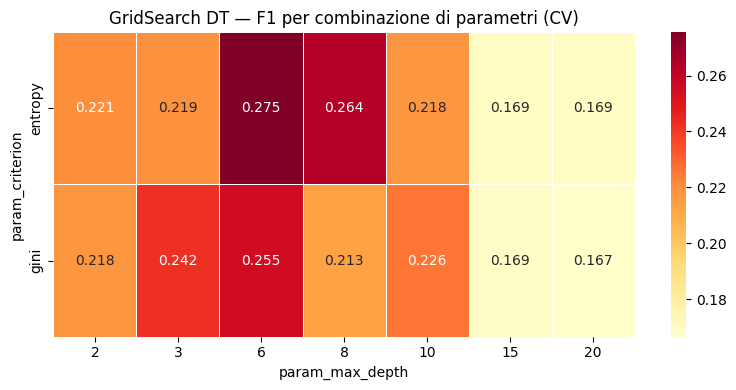

In [8]:
param_grid_dt = {'criterion': ['entropy', 'gini'],'max_depth': [2, 3, 6, 8 ,10, 15, 20, None]}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=random_seed),
    param_grid_dt,
    cv=skf,
    scoring='f1',
    refit=True,  # riaddestra il best model sull'intero X_train
    n_jobs=-1
)
gs_dt.fit(X_train, y_train)

print(f"Migliori parametri DT: {gs_dt.best_params_}")
print(f"Miglior F1 (CV):       {gs_dt.best_score_:.4f}")

plot_gridsearch_heatmap(gs_dt,
    param_x='param_max_depth',
    param_y='param_criterion',
    title='GridSearch DT — F1 per combinazione di parametri (CV)')

best_dt = gs_dt.best_estimator_

In [9]:
# Valutazione finale 
dt_pred = best_dt.predict(X_test)
dt_prob = best_dt.predict_proba(X_test)[:, 1]
res_dt = evaluate(y_test, dt_pred, dt_prob, 'Decision Tree')

=== Decision Tree ===
              precision    recall  f1-score   support

     Rimasto       0.85      0.37      0.52       127
      Uscito       0.16      0.65      0.25        23

    accuracy                           0.41       150
   macro avg       0.51      0.51      0.39       150
weighted avg       0.75      0.41      0.48       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             47            80
Reale: Uscito               8            15



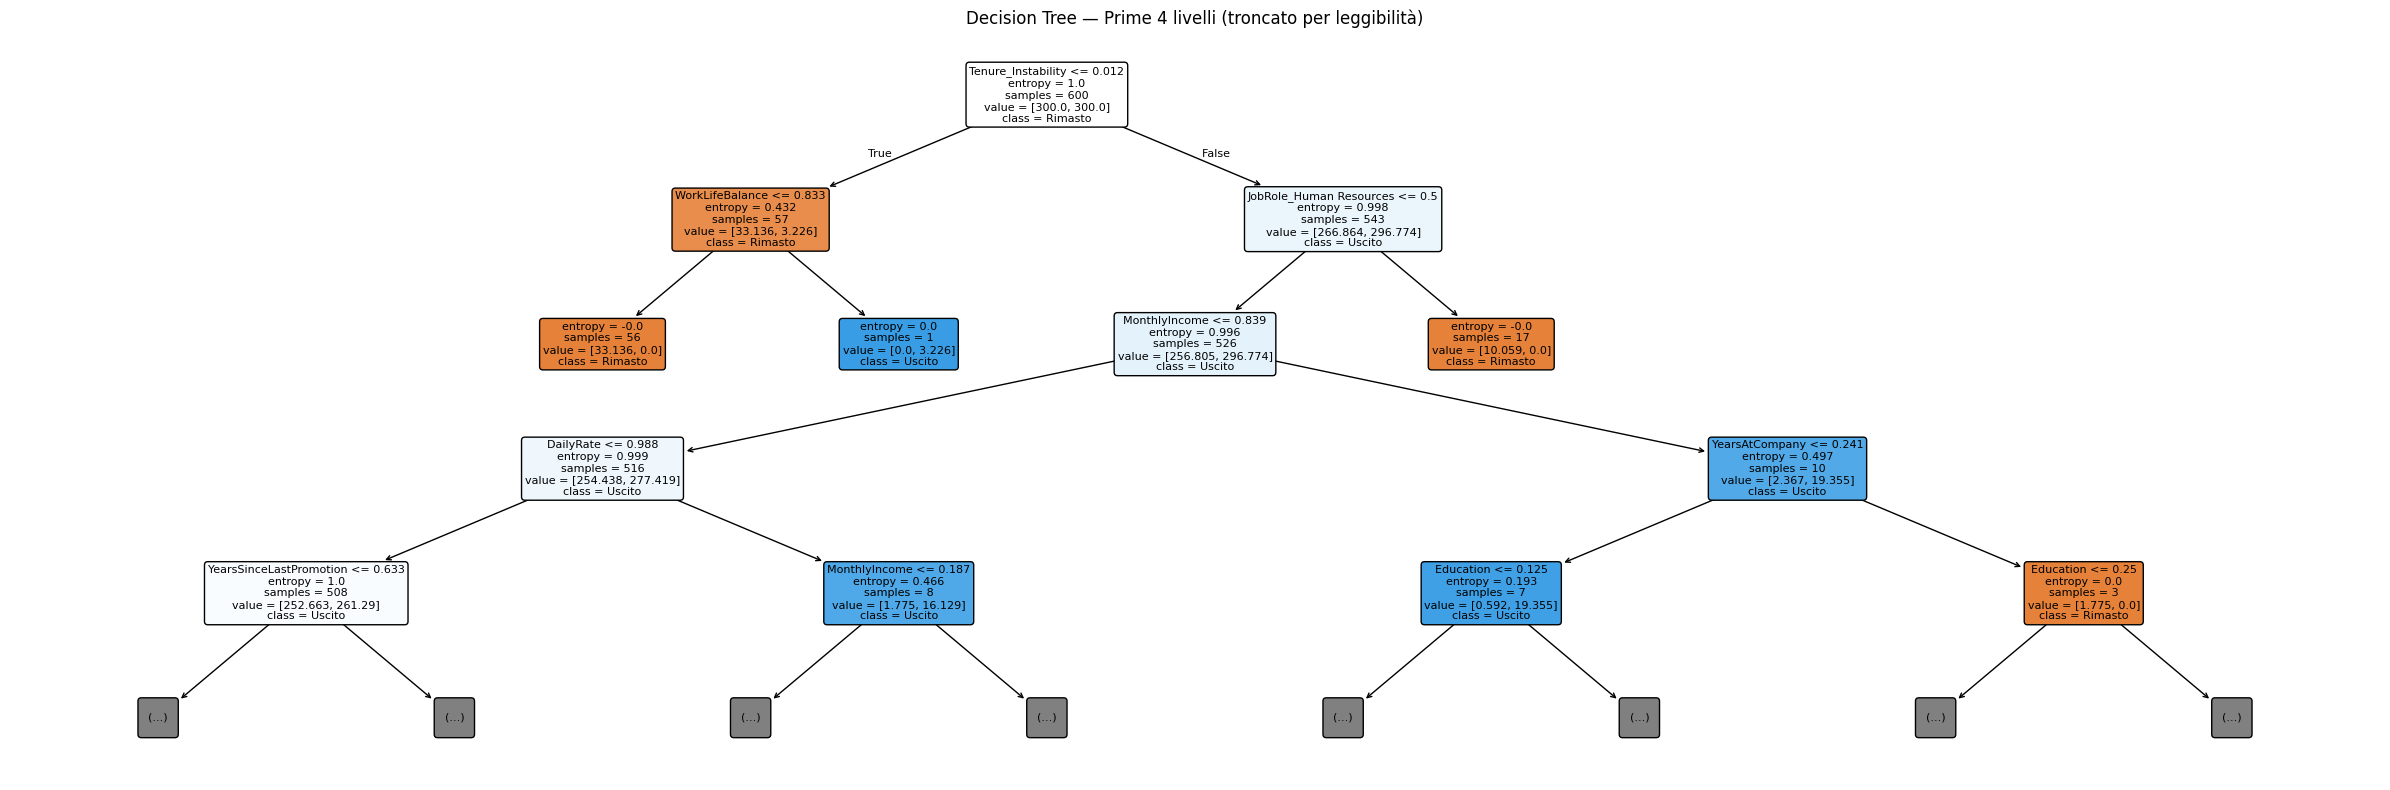

|--- Tenure_Instability <= 0.01
|   |--- WorkLifeBalance <= 0.83
|   |   |--- class: 0
|   |--- WorkLifeBalance >  0.83
|   |   |--- class: 1
|--- Tenure_Instability >  0.01
|   |--- JobRole_Human Resources <= 0.50
|   |   |--- MonthlyIncome <= 0.84
|   |   |   |--- DailyRate <= 0.99
|   |   |   |   |--- YearsSinceLastPromotion <= 0.63
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- YearsSinceLastPromotion >  0.63
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- DailyRate >  0.99
|   |   |   |   |--- MonthlyIncome <= 0.19
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- MonthlyIncome >  0.19
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- MonthlyIncome >  0.84
|   |   |   |--- YearsAtCompany <= 0.24
|   |   |   |   |--- Education <= 0.12
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Education >  0.12
|   |   |   |   |   |--- class: 1
|   |   |   |--- YearsAtCompany >  0.24
|   |   |   |   |--- Education <= 

In [10]:
# Visualizzazione dell'albero — utile per estrarre business rules interpretabili.
# Limitiamo a max_depth=4 per leggibilità anche se il modello è più profondo.
plt.figure(figsize=(24, 8))
plot_tree(best_dt,feature_names=X_train.columns,class_names=['Rimasto', 'Uscito'],filled=True,max_depth=4,fontsize=8,impurity=True,rounded=True)
plt.title('Decision Tree — Prime 4 livelli (troncato per leggibilità)')
plt.tight_layout()
plt.show()

# Versione testuale delle regole — più facile da leggere e presentare
print(export_text(best_dt, feature_names=list(X_train.columns), max_depth=4))

## 4. Random Forest

Il Random Forest è un metodo ensemble che addestra T alberi decisionali su
campioni bootstrap del dataset (bagging), usando a ogni split un sottoinsieme
casuale di feature di dimensione √p. La predizione finale è il voto di maggioranza:

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

Rispetto al singolo Decision Tree, il Random Forest riduce la varianza mantenendo
bias basso, ed è robusto a rumore e outlier. Il trade-off è la perdita di
interpretabilità: la predizione dipende da centinaia di alberi e non è
direttamente leggibile. Viene però fornita la feature importance globale,
che stima il contributo di ogni variabile alla classificazione.

Migliori parametri RF: {'max_depth': 2, 'n_estimators': 20}
Miglior F1 (CV):       0.2503


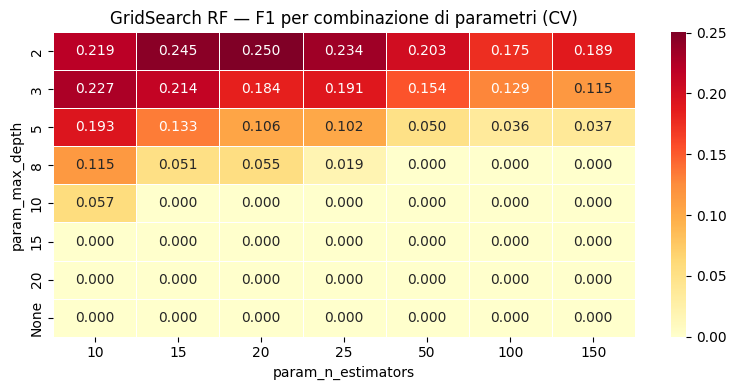

In [11]:
param_grid_rf = {'n_estimators': [10, 15, 20, 25, 50, 100, 150],'max_depth':  [2, 3, 5, 8, 10, 15, 20, None]}

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=random_seed, n_jobs=-1),
    param_grid_rf,
    cv=skf,
    scoring='f1',
    refit=True,
    n_jobs=-1,
)
gs_rf.fit(X_train, y_train)

print(f"Migliori parametri RF: {gs_rf.best_params_}")
print(f"Miglior F1 (CV):       {gs_rf.best_score_:.4f}")

plot_gridsearch_heatmap(gs_rf,
    param_x='param_n_estimators',
    param_y='param_max_depth',
    title='GridSearch RF — F1 per combinazione di parametri (CV)')

best_rf = gs_rf.best_estimator_

In [12]:
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

res_rf = evaluate(y_test, rf_pred, rf_prob, 'Random Forest')

=== Random Forest ===
              precision    recall  f1-score   support

     Rimasto       0.84      0.60      0.70       127
      Uscito       0.14      0.35      0.20        23

    accuracy                           0.56       150
   macro avg       0.49      0.47      0.45       150
weighted avg       0.73      0.56      0.62       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             76            51
Reale: Uscito              15             8



C:\Users\andre\AppData\Local\Temp\ipykernel_27568\2663478048.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances.head(15), x='Importance', y='Feature', palette='magma')


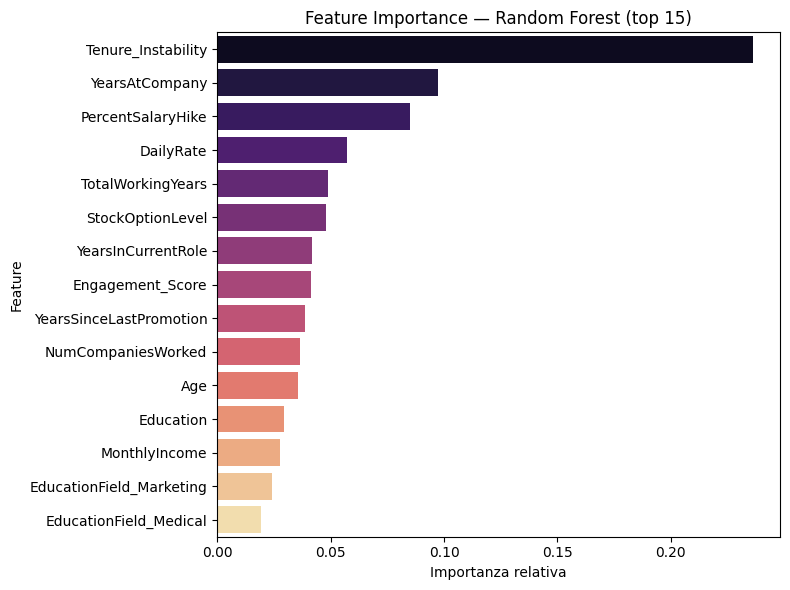

Top 10 feature più importanti:
                    Feature  Importance
23       Tenure_Instability      0.2363
16           YearsAtCompany      0.0974
7         PercentSalaryHike      0.0848
5                 DailyRate      0.0574
15        TotalWorkingYears      0.0487
8          StockOptionLevel      0.0481
17       YearsInCurrentRole      0.0418
22         Engagement_Score      0.0413
18  YearsSinceLastPromotion      0.0386
20       NumCompaniesWorked      0.0367


In [13]:
# La feature importance del RF misura quanto ogni variabile riduce
# l'impurità media pesata sui nodi in cui viene usata, mediata su tutti gli alberi.
rf_importances = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importances.head(15), x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance — Random Forest (top 15)')
plt.xlabel('Importanza relativa')
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti:')
print(rf_importances.head(10).round(4).to_string())

## 8. Analisi Comparativa


               Accuracy  Precision  Recall      F1     AUC
Modello                                                   
Decision Tree    0.4133     0.1579  0.6522  0.2542  0.5286
Random Forest    0.5600     0.1356  0.3478  0.1951  0.5142


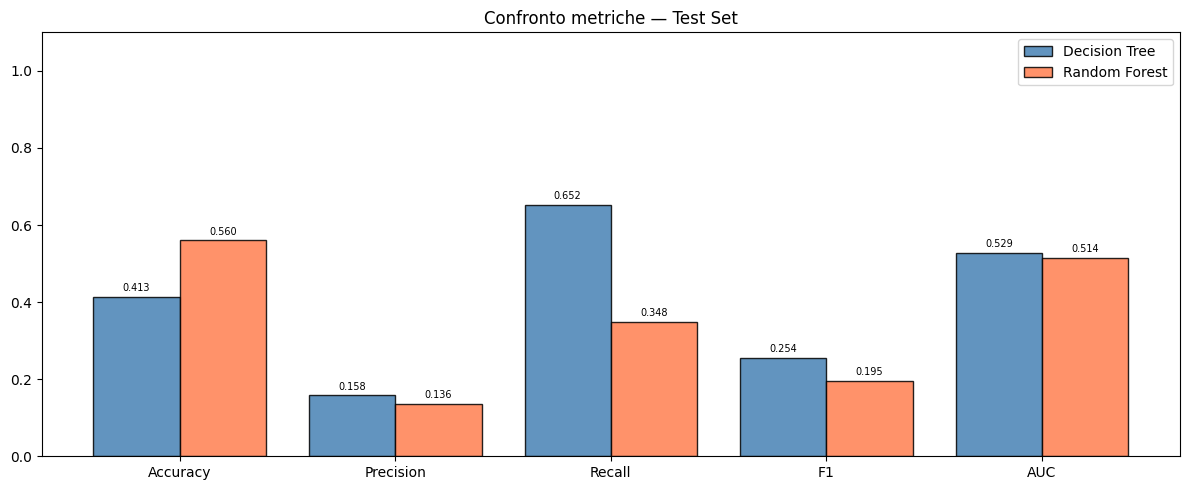

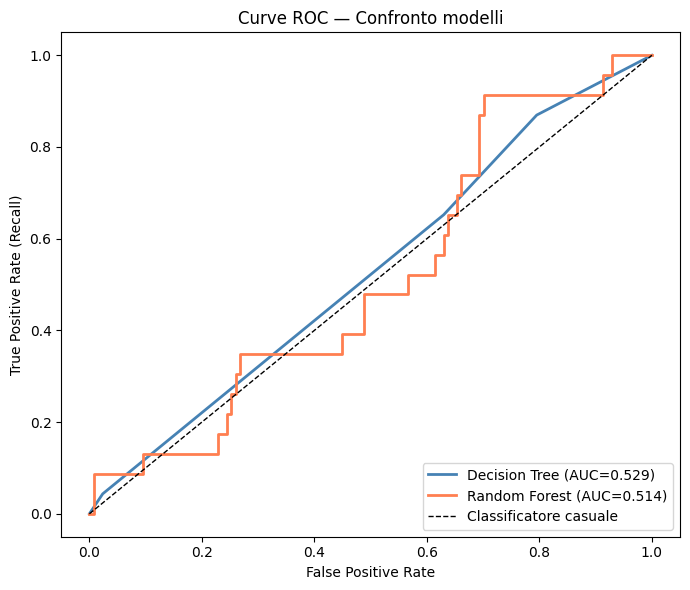

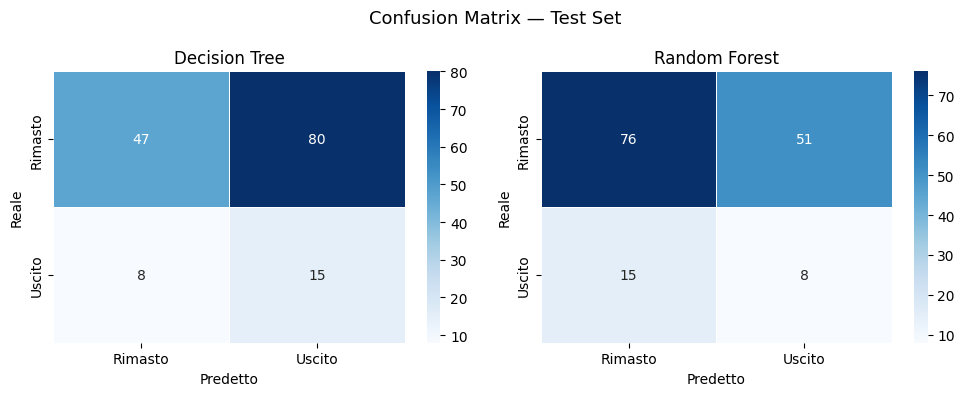

In [14]:
results = [res_dt, res_rf]
# Tabella riassuntiva
summary = pd.DataFrame([
    {k: v for k, v in res.items() if k not in ['y_pred', 'y_prob']}
    for res in results
]).set_index('Modello').round(4)

print(summary)

# Barplot comparativo
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x      = np.arange(len(metrics))
width  = 0.8 / len(results)  # larghezza barre si adatta al numero di modelli
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

fig, ax = plt.subplots(figsize=(12, 5))
for i, res in enumerate(results):
    vals = [summary.loc[res['Modello'], m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=res['Modello'],
                  color=colors[i], edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * (len(results) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Confronto metriche — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

# Curve ROC
plt.figure(figsize=(7, 6))
for res, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, linewidth=2, color=color,
             label=f"{res['Modello']} (AUC={res['AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificatore casuale')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curve ROC — Confronto modelli')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Confusion matrix affiancate
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]
for ax, res in zip(axes, results):
    sns.heatmap(confusion_matrix(y_test, res['y_pred']),
                annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rimasto', 'Uscito'],
                yticklabels=['Rimasto', 'Uscito'],
                linewidths=0.5)
    ax.set_title(res['Modello'])
    ax.set_xlabel('Predetto')
    ax.set_ylabel('Reale')
plt.suptitle('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# SOLO PER CAPIRE GLI ATTRIBUTI DA TENERE NELLA FEATURE SELECTION

from itertools import combinations
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, recall_score, roc_auc_score


# controlliamo le variabili che andremmo a togliere nella feature selection, proviamo a creare le varie combinazione e capire
# qual è la combinazione migliore
candidate_cols = ['Engagement_Score', 'Tenure_Instability', 'HourlyRate', 'DailyRate']

all_subsets = []
for r in range(len(candidate_cols) + 1):
    for combo in combinations(candidate_cols, r):
        all_subsets.append(list(combo))

print(f"Combinazioni da testare: {len(all_subsets)}\n")
print(f"{'Rimosse':<50} {'F1_DT':>6} {'Rec_DT':>7} {'AUC_DT':>7} | {'F1_RF':>6} {'Rec_RF':>7} {'AUC_RF':>7} {'N':>4}")
print("-" * 105)

results_ablation = []

for cols_removed in all_subsets:
    X = X_train.drop(columns=cols_removed, errors='ignore')

    # DT — con i best params trovati dalla GridSearch
    dt_clf  = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=random_seed,
        criterion=gs_dt.best_params_['criterion'],
        max_depth=gs_dt.best_params_['max_depth']
    )
    dt_pred = cross_val_predict(dt_clf, X, y_train, cv=skf)
    dt_prob = cross_val_predict(dt_clf, X, y_train, cv=skf, method='predict_proba')[:, 1]
    f1_dt  = f1_score(y_train, dt_pred, zero_division=0)
    rec_dt = recall_score(y_train, dt_pred, zero_division=0)
    auc_dt = roc_auc_score(y_train, dt_prob)

    # RF — con i best params trovati dalla GridSearch
    rf_clf  = RandomForestClassifier(
        class_weight='balanced',
        random_state=random_seed,
        n_jobs=-1,
        criterion=gs_rf.best_params_.get('criterion', 'entropy'),
        max_depth=gs_rf.best_params_['max_depth'],
        n_estimators=gs_rf.best_params_['n_estimators']
    )
    rf_pred = cross_val_predict(rf_clf, X, y_train, cv=skf)
    rf_prob = cross_val_predict(rf_clf, X, y_train, cv=skf, method='predict_proba')[:, 1]
    f1_rf  = f1_score(y_train, rf_pred, zero_division=0)
    rec_rf = recall_score(y_train, rf_pred, zero_division=0)
    auc_rf = roc_auc_score(y_train, rf_prob)

    label = str(cols_removed) if cols_removed else '[] (nessuna rimossa)'
    print(f"{label:<50} {f1_dt:>6.3f} {rec_dt:>7.3f} {auc_dt:>7.3f} | {f1_rf:>6.3f} {rec_rf:>7.3f} {auc_rf:>7.3f} {X.shape[1]:>4}")

    results_ablation.append({
        'Rimosse': cols_removed,
        'F1_DT': f1_dt, 'Recall_DT': rec_dt, 'AUC_DT': auc_dt,
        'F1_RF': f1_rf, 'Recall_RF': rec_rf, 'AUC_RF': auc_rf,
        'N_feat': X.shape[1]
    })

df_abl = pd.DataFrame(results_ablation)

print("\n" + "=" * 105)
print("Miglior config per F1 DT:")
print(df_abl.loc[df_abl['F1_DT'].idxmax()][['Rimosse','F1_DT','Recall_DT','AUC_DT']].to_string())

print("\nMiglior config per Recall DT:")
print(df_abl.loc[df_abl['Recall_DT'].idxmax()][['Rimosse','Recall_DT','F1_DT','AUC_DT']].to_string())

print("\nMiglior config per AUC DT:")
print(df_abl.loc[df_abl['AUC_DT'].idxmax()][['Rimosse','Recall_RF','F1_RF','AUC_RF']].to_string())

print("\nMiglior config per F1 RF:")
print(df_abl.loc[df_abl['F1_RF'].idxmax()][['Rimosse','F1_RF','Recall_RF','AUC_RF']].to_string())

print("\nMiglior config per Recall RF:")
print(df_abl.loc[df_abl['Recall_RF'].idxmax()][['Rimosse','Recall_RF','F1_RF','AUC_RF']].to_string())

print("\nMiglior config per AUC RF:")
print(df_abl.loc[df_abl['AUC_RF'].idxmax()][['Rimosse','Recall_RF','F1_RF','AUC_RF']].to_string())


Combinazioni da testare: 16

Rimosse                                             F1_DT  Rec_DT  AUC_DT |  F1_RF  Rec_RF  AUC_RF    N
---------------------------------------------------------------------------------------------------------
[] (nessuna rimossa)                                0.278   0.591   0.558 |  0.238   0.387   0.531   51
['Engagement_Score']                                0.269   0.613   0.539 |  0.243   0.333   0.539   50
['Tenure_Instability']                              0.228   0.581   0.447 |  0.215   0.269   0.520   50
['HourlyRate']                                      0.258   0.559   0.517 |  0.209   0.312   0.556   50
['DailyRate']                                       0.239   0.441   0.506 |  0.241   0.387   0.560   50
['Engagement_Score', 'Tenure_Instability']          0.240   0.570   0.477 |  0.150   0.204   0.460   49
['Engagement_Score', 'HourlyRate']                  0.263   0.591   0.531 |  0.205   0.301   0.533   49
['Engagement_Score', 'DailyRate']

Problema:
F1 — media armonica tra precision e recall. Buono sopra 0.6, ottimo sopra 0.75. I tuoi valori (0.11-0.18) sono molto bassi, il modello fatica a trovare chi se ne va.
Recall — su tutti i dipendenti che effettivamente escono, quanti ne cattura il modello. In HR è la metrica più importante: un recall basso significa che stai perdendo di vista molti dipendenti a rischio. Buono sopra 0.6. I tuoi (0.12-0.19) sono bassi.
AUC — misura quanto bene il modello separa le due classi indipendentemente dalla soglia. Va da 0.5 (casuale) a 1.0 (perfetto). Buono sopra 0.75, accettabile tra 0.65-0.75. I tuoi (0.47-0.54) sono sostanzialmente casuali — il modello non riesce a distinguere chi esce da chi resta.
Anche nella configurazione migliore di attributi non è comunque buona